In [3]:
import os
from tqdm.auto import tqdm

import numpy as np
import matplotlib.pyplot as plt 
from PIL import Image

# Track 1 data path

In [4]:
data_path = '../data/raw/dataset_CIDIS_sisr_x8/thermal'
print(data_path)

../data/raw/dataset_CIDIS_sisr_x8/thermal


In [5]:
print(os.listdir(data_path))
print(len(os.listdir(data_path)))

['test', 'train', 'val']
3


In [6]:
train_path_LR = os.path.join(data_path, 'train', 'LR_x8')
train_path_GT = os.path.join(data_path, 'train', 'GT')
len(os.listdir(train_path_LR))

700

In [7]:
val_path_LR = os.path.join(data_path, 'val', 'LR_x8')
val_path_GT = os.path.join(data_path, 'val', 'GT')
len(os.listdir(val_path_LR))

200

In [8]:
test_path = os.path.join(data_path, 'test', 'sisr_x8', 'LR_x8')
len(os.listdir(test_path))

20

In [9]:
train_GT = os.listdir(train_path_GT)
train_GT[1]

'004_01_D2_th.bmp'

In [37]:
def Distribution_of_image_size(data_path, split='train'):

    LR_H = []
    LR_W = []
    GT_H = []
    GT_W = []

    split_path = os.path.join(data_path, split)

    LR_path = os.path.join(split_path, 'LR_x8')
    GT_path = os.path.join(split_path, 'GT')

    LR_name = os.listdir(LR_path)
    GT_name = os.listdir(GT_path)

    print(f'Number of LR/GT image: {len(LR_name)}, {len(GT_name)}')
    
    

    for item in LR_name:
        LR_image = Image.open(os.path.join(LR_path, item))
        LR_image = np.array(LR_image)
        H, W, _ = LR_image.shape
        LR_H.append(H)
        LR_W.append(W)
    
    for item in GT_name:
        GT_image = Image.open(os.path.join(GT_path, item))
        GT_image = np.array(GT_image)
        H, W, _ = GT_image.shape
        GT_H.append(H)
        GT_W.append(W)

    plt.figure(figsize=(6, 4))
    plt.scatter(LR_W, LR_H, c='blue', marker='x', label='LR')
    plt.scatter(GT_W, GT_H, c='orange', marker='x', label='GT')
    plt.xlabel('Width')
    plt.ylabel('Height')
    plt.title('Distribution of image size')
    plt.show()

Number of LR/GT image: 700, 700


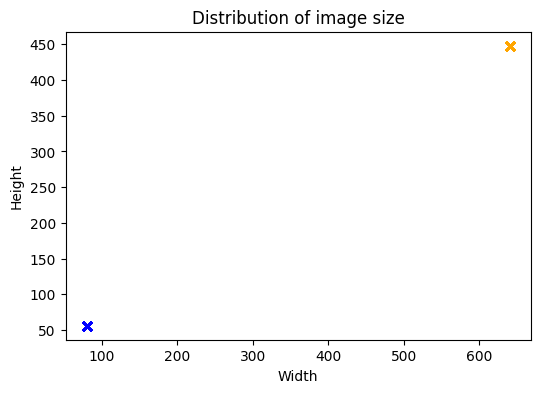

In [38]:
Distribution_of_image_size(data_path, 'train')

Number of LR/GT image: 200, 200


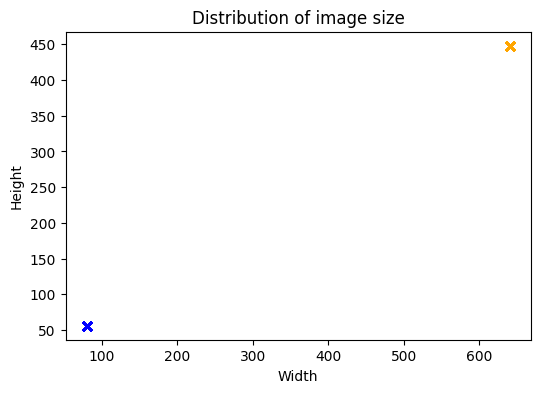

In [39]:
Distribution_of_image_size(data_path, 'val')


In [40]:
def show_pair(data_path, split, index):
    
    LR_path = os.path.join(data_path, split, 'LR_x8')
    GT_path = os.path.join(data_path, split, 'GT')
    
    LR_names = sorted(os.listdir(LR_path))
    GT_names = sorted(os.listdir(GT_path))
    
    lr_img = np.array(Image.open(os.path.join(LR_path, LR_names[index])))
    gt_img = np.array(Image.open(os.path.join(GT_path, GT_names[index])))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].imshow(lr_img)
    axes[0].set_title(f'LR: {LR_names[index]}\n{lr_img.shape} - {lr_img.dtype}')
    axes[0].axis('off')
    
    axes[1].imshow(gt_img)
    axes[1].set_title(f'GT: {GT_names[index]}\n{gt_img.shape} - {gt_img.dtype}')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()


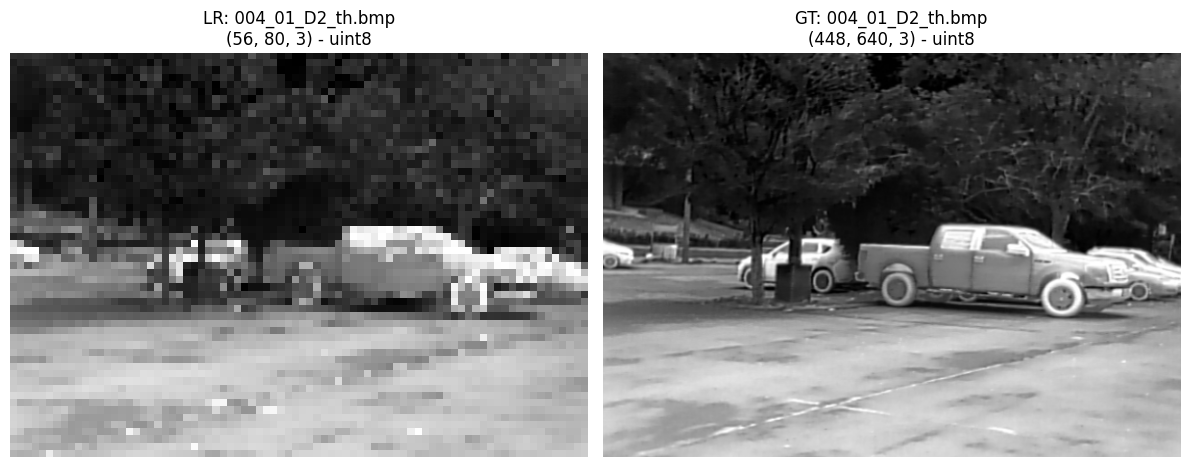

In [41]:
show_pair(data_path, 'train', 1)